In [1]:
import figure_settings
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from figure_settings import style_settings
from scipy import stats

from conus_biomass import dir_info
from conus_biomass.make_figures import maps

# Load data

In [2]:
# Load saved figure data
save_dir = "figure_data/figure_4/"

biomass_delta_actual = xr.open_dataset(save_dir + "biomass_delta_actual.nc")["biomass_delta_actual"]
biomass_delta_modeled = xr.open_dataset(save_dir + "biomass_delta_modeled.nc")[
    "biomass_delta_modeled"
]
ds_binned = xr.open_dataset(save_dir + "ds_binned_actual.nc")
ds_binned_counts = xr.open_dataset(save_dir + "ds_binned_counts_actual.nc")
ds_binned_modeled = xr.open_dataset(save_dir + "ds_binned_modeled.nc")
ds_binned_modeled_counts = xr.open_dataset(save_dir + "ds_binned_counts_modeled.nc")

with open(save_dir + "target_crs.txt") as f:
    target_crs = f.read()

In [3]:
biomass_delta_modeled = biomass_delta_modeled.where(~np.isnan(biomass_delta_actual), drop=True)
ds_binned_counts = ds_binned_counts.where(~np.isnan(ds_binned_counts), drop=True)
ds_binned_modeled_counts = ds_binned_modeled_counts.where(
    ~np.isnan(ds_binned_modeled_counts), drop=True
)
biomass_delta_actual = biomass_delta_actual.where(~np.isnan(biomass_delta_actual), drop=True)

# Make figure

In [4]:
from scipy import odr

x = ds_binned["biomass_delta_actual"].where(ds_binned_counts["n_plots"] >= 10).values.flatten()
y = (
    ds_binned_modeled["biomass_delta_modeled"]
    .where(ds_binned_modeled_counts["n_plots"] >= 10)
    .values.flatten()
)
nanfilter = (~np.isnan(x)) * (~np.isnan(y))

x_clean = x[nanfilter]
y_clean = y[nanfilter]


def linear_func(B, x):
    return B[0] * x + B[1]


model = odr.Model(linear_func)
data = odr.Data(x_clean, y_clean)
result = odr.ODR(data, model, beta0=[1, 0]).run()

slope, intercept = result.beta
r, p = stats.pearsonr(x_clean, y_clean)

r2 = r**2
x_fit = np.array([np.nanmin(x_clean), np.nanmax(y_clean)])

In [5]:
SCATTER_XMIN, SCATTER_XMAX = -71, 43
PANEL_LABEL_FONTSIZE = style_settings["axes.titlesize"] * 1.25  # or just 35

/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_81408/2049441904.py:96: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.05, right=0.95, bottom=0.02, top=0.92, wspace=-0.05)


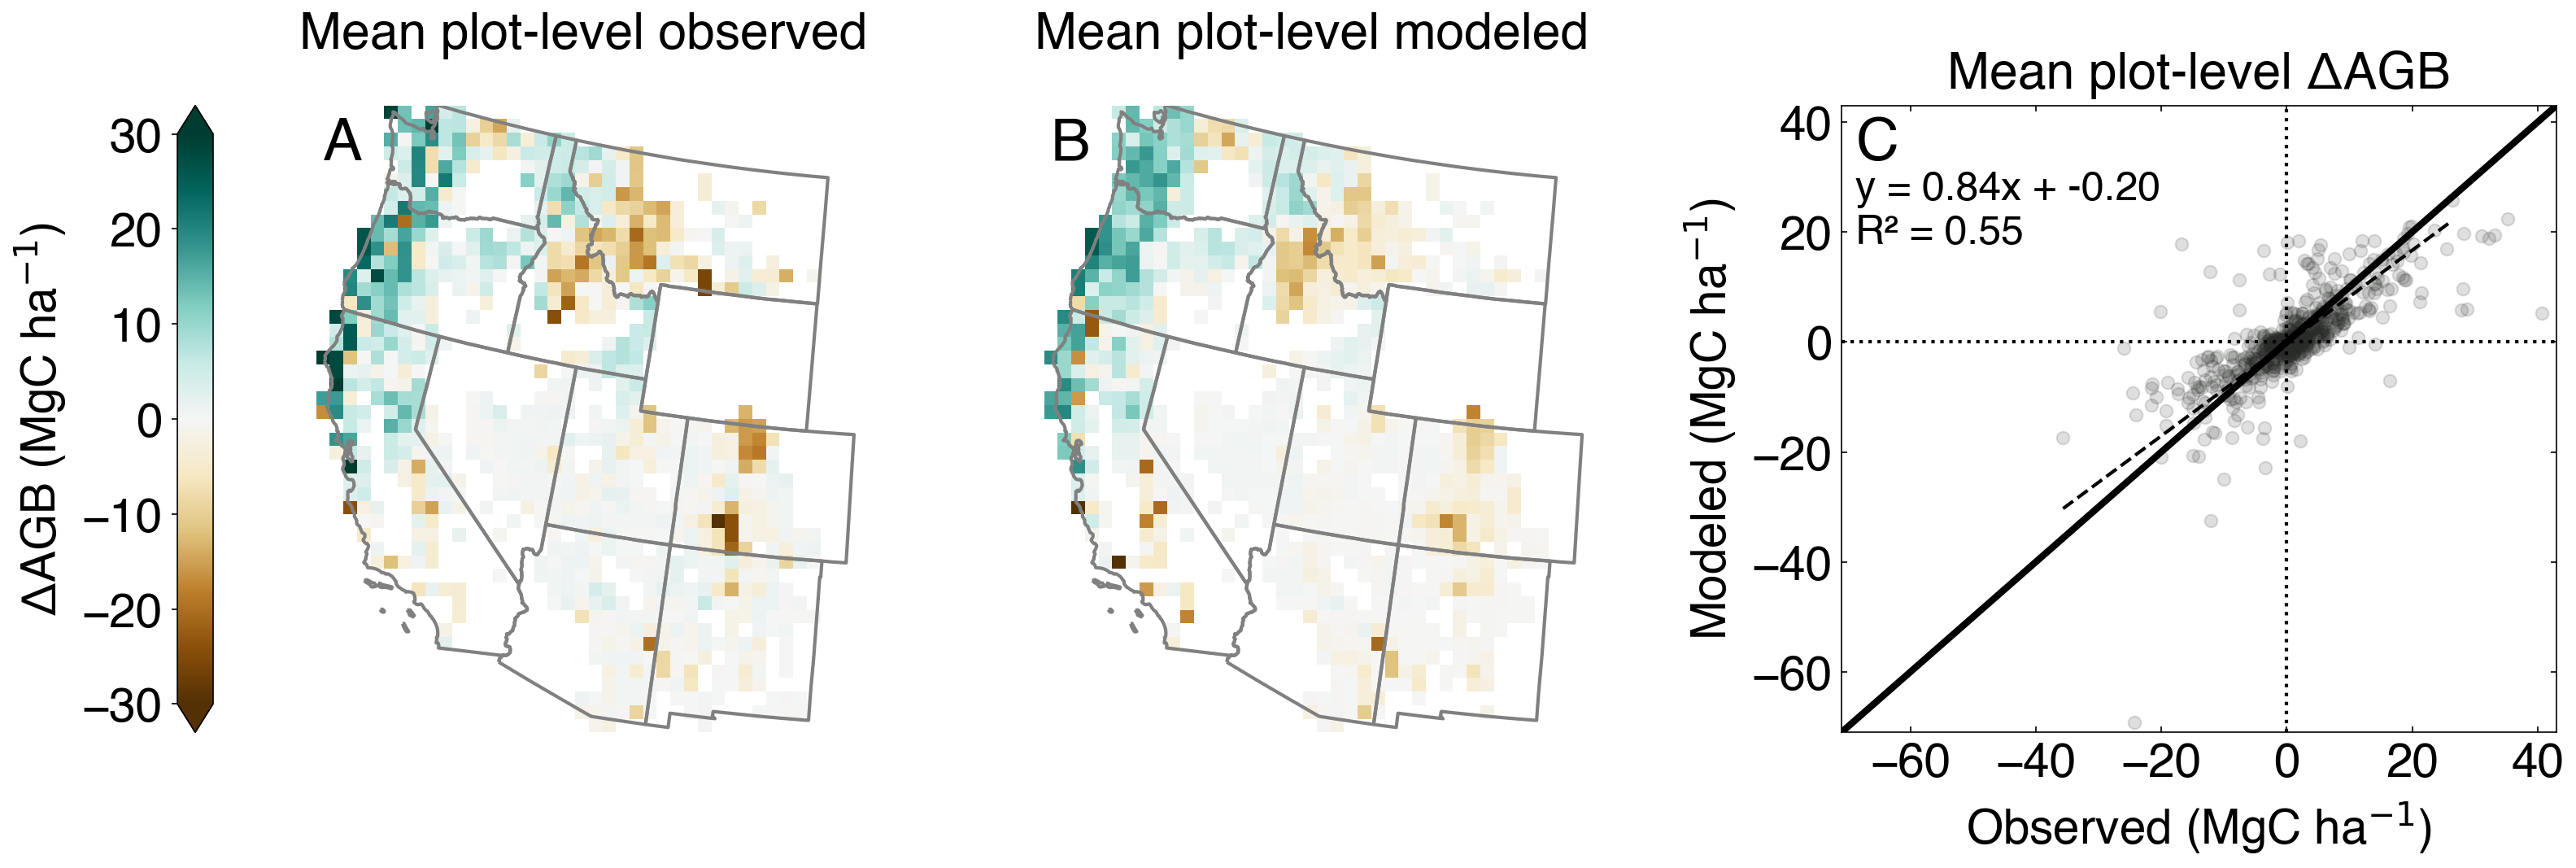

In [6]:
figure_settings.apply_style()

fig, axs = plt.subplots(
    1, 4, figsize=(21, 7), gridspec_kw={"width_ratios": [0.05, 1, 1, 1]}, constrained_layout=True
)

cmap = plt.cm.BrBG
clims = [-30, 30]
shp_native = maps.SHP_WESTERN.to_crs(target_crs)


def setup_ax(ax):
    ax.set_axis_off()
    shp_native.boundary.plot(ax=ax, color="gray", linewidth=style_settings["lines.linewidth"] / 4)
    ax.set_xlim([-2.4e6, -0.5e6])


cbar_ax = axs[0]

##############################################################################################################
##############################################################################################################

ax = axs[1]
im = biomass_delta_actual.plot(ax=ax, vmin=clims[0], vmax=clims[1], cmap=cmap, add_colorbar=False)
ax.set_title("Mean plot-level observed")
setup_ax(ax)
##############################################################################################################
##############################################################################################################

ax = axs[2]
im = biomass_delta_modeled.plot(ax=ax, vmin=clims[0], vmax=clims[1], cmap=cmap, add_colorbar=False)
ax.set_title("Mean plot-level modeled")
setup_ax(ax)

cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical", extend="both")
cbar.set_label("ΔAGB (MgC ha$^{-1}$)")
cbar.ax.tick_params(direction="out")
cbar_ax.yaxis.set_ticks_position("left")
cbar_ax.yaxis.set_label_position("left")

##############################################################################################################
##############################################################################################################
ax = axs[3]

ax.plot(
    x[nanfilter],
    y[nanfilter],
    ".",
    color=figure_settings.color_this_study,
    markersize=15,
    alpha=0.15,
)
ax.set_xlabel("Observed (MgC ha$^{-1}$)")
ax.set_ylabel("Modeled (MgC ha$^{-1}$)")
ax.plot(
    [SCATTER_XMIN, SCATTER_XMAX],
    [SCATTER_XMIN, SCATTER_XMAX],
    "k",
    linewidth=style_settings["lines.linewidth"] / 2,
)
ax.axhline(y=0, linestyle=":", color="k", linewidth=style_settings["lines.linewidth"] / 4)
ax.axvline(x=0, linestyle=":", color="k", linewidth=style_settings["lines.linewidth"] / 4)
ax.set_xlim([SCATTER_XMIN, SCATTER_XMAX])
ax.set_ylim([SCATTER_XMIN, SCATTER_XMAX])
ticks = np.arange(-60, SCATTER_XMAX + 1, 20)  # adjust step size as needed
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.plot(
    x_fit,
    slope * x_fit + intercept,
    "--",
    color="k",
    linewidth=style_settings["lines.linewidth"] / 4,
    label=f"fit (y = {slope:.2f}x+{intercept:.2f})",
)
ax.text(0.02, 0.85, f"y = {slope:.2f}x + {intercept:.2f}", transform=ax.transAxes, fontsize=24)
ax.text(0.02, 0.78, f"R² = {r2:.2f}", transform=ax.transAxes, fontsize=24)
ax.set_title("Mean plot-level ΔAGB")

##############################################################################################################
##############################################################################################################


panel_labels = ["A", "B", "C"]
for i, ax in enumerate(axs[1:]):
    ax.text(
        0.02,
        0.98,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=28 * 1.25,
        fontweight="bold",
        va="top",
    )

# fig.get_layout_engine().set(w_pad=0, h_pad=0, hspace=0, wspace=0.05)
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.02, top=0.92, wspace=-0.05)

# fig.savefig(dir_info.dir_figures + "Figure4.jpg", bbox_inches="tight", dpi=300)
# fig.savefig(dir_info.dir_figures + "Figure4.pdf", bbox_inches="tight")

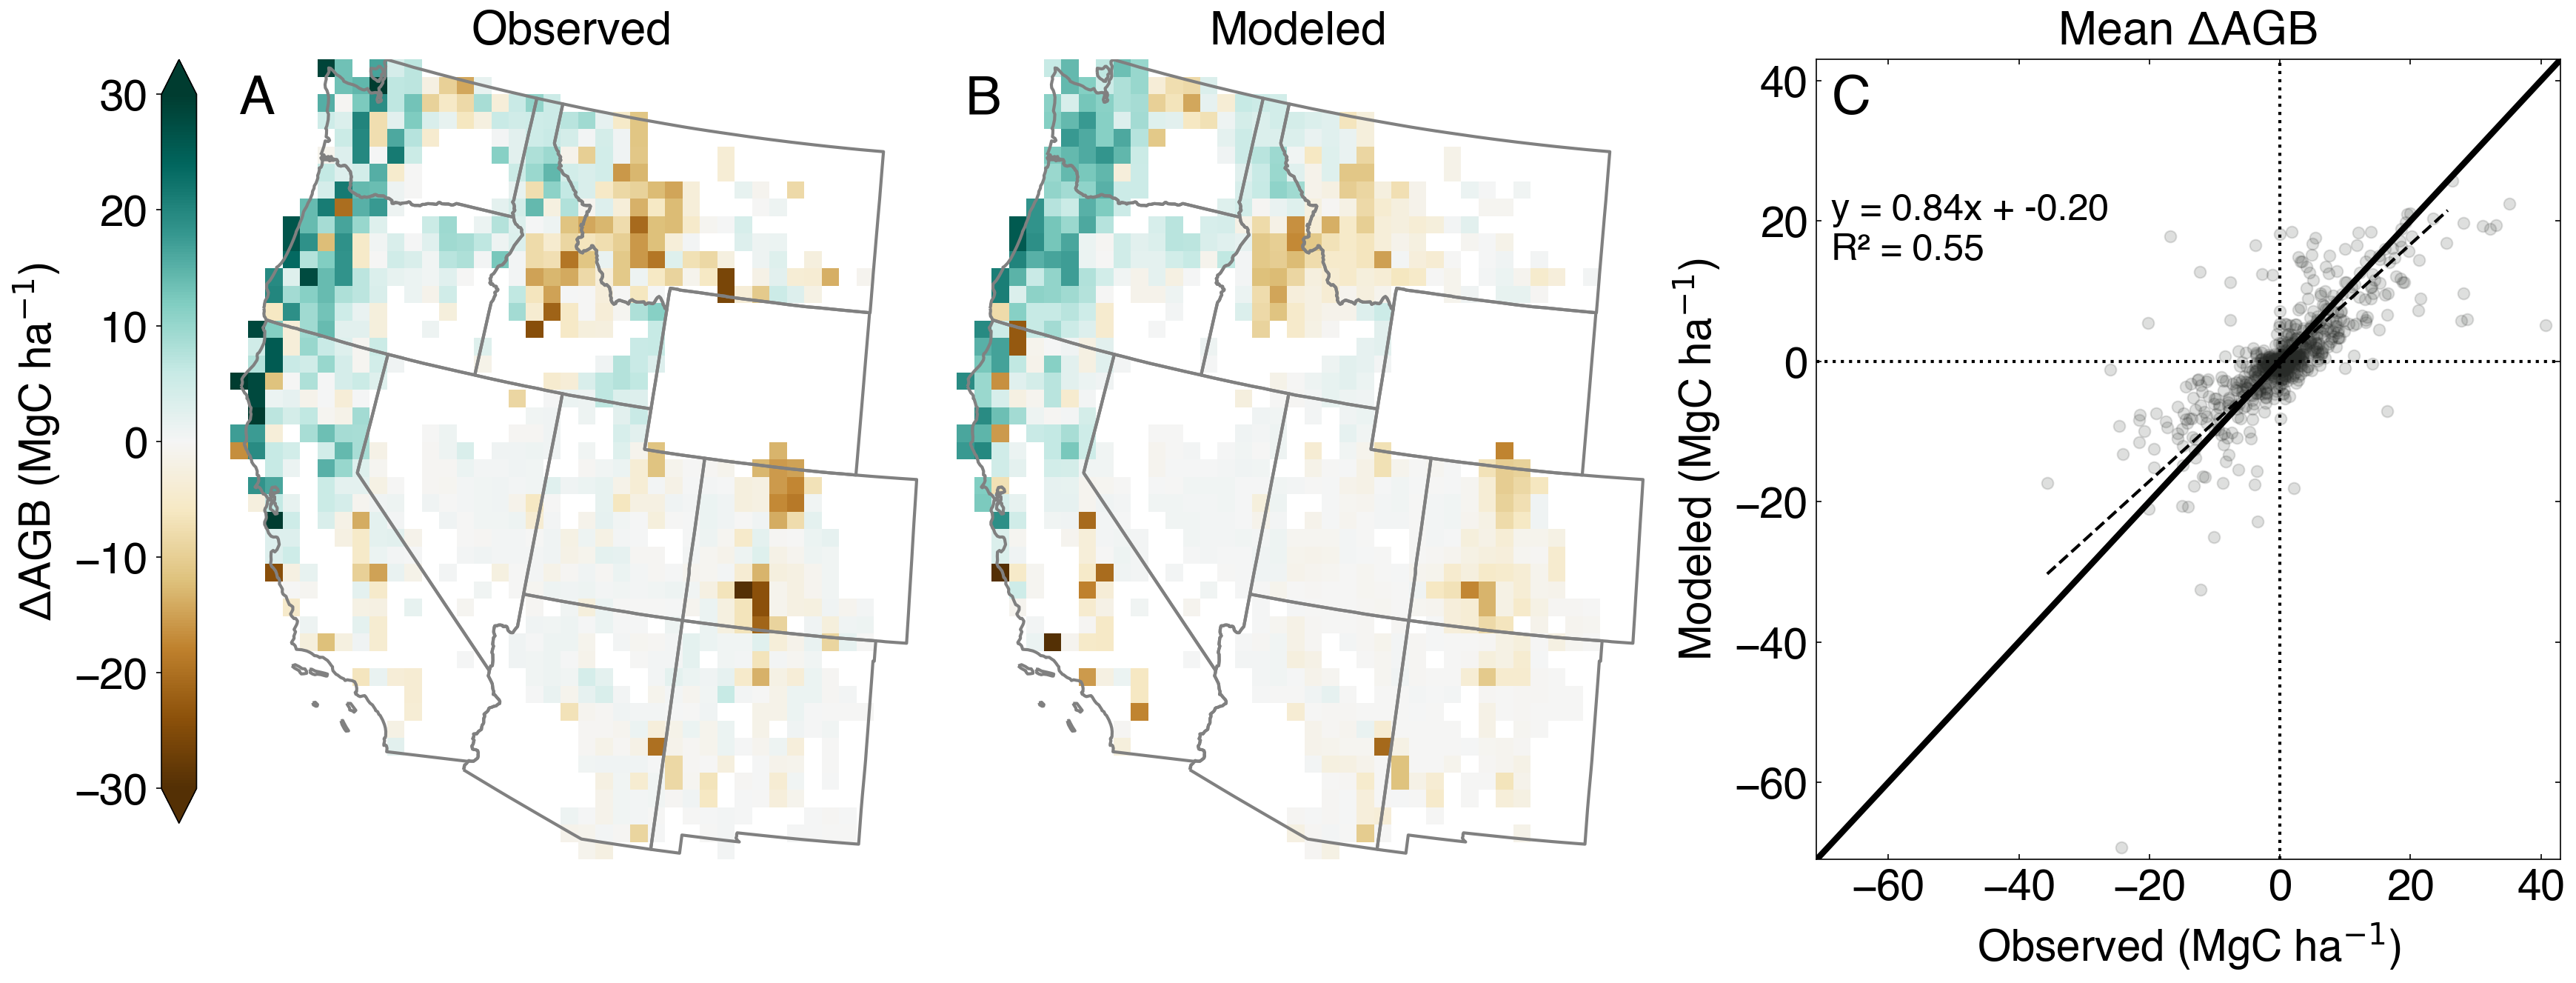

In [7]:
import os

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

figure_settings.apply_style()

cmap = plt.cm.BrBG
clims = [-30, 30]
shp_native = maps.SHP_WESTERN.to_crs(target_crs)

fig = plt.figure(figsize=(24, 8))
gs = GridSpec(
    1, 2, width_ratios=[2, 1], wspace=0.15, figure=fig, left=0.05, right=0.95, bottom=0.02, top=0.92
)

gs_left = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0], width_ratios=[0.05, 1, 1], wspace=0.05)
cbar_ax = fig.add_subplot(gs_left[0])
ax1 = fig.add_subplot(gs_left[1])
ax2 = fig.add_subplot(gs_left[2])
ax3 = fig.add_subplot(gs[1])

axs = [cbar_ax, ax1, ax2, ax3]


def setup_ax(ax):
    ax.set_axis_off()
    shp_native.boundary.plot(ax=ax, color="gray", linewidth=style_settings["lines.linewidth"] / 4)
    ax.set_xlim([-2.4e6, -0.5e6])


# Panel A
im = biomass_delta_actual.plot(ax=ax1, vmin=clims[0], vmax=clims[1], cmap=cmap, add_colorbar=False)
ax1.set_title("Observed")
setup_ax(ax1)

# Panel B
im = biomass_delta_modeled.plot(ax=ax2, vmin=clims[0], vmax=clims[1], cmap=cmap, add_colorbar=False)
ax2.set_title("Modeled")
setup_ax(ax2)

cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical", extend="both")
cbar.set_label("ΔAGB (MgC ha$^{-1}$)")
cbar.ax.tick_params(direction="out")
cbar_ax.yaxis.set_ticks_position("left")
cbar_ax.yaxis.set_label_position("left")

# Panel C
ax3.plot(
    x[nanfilter],
    y[nanfilter],
    ".",
    color=figure_settings.color_this_study,
    markersize=15,
    alpha=0.15,
)
ax3.set_xlabel("Observed (MgC ha$^{-1}$)")
ax3.set_ylabel("Modeled (MgC ha$^{-1}$)")
ax3.plot(
    [SCATTER_XMIN, SCATTER_XMAX],
    [SCATTER_XMIN, SCATTER_XMAX],
    "k",
    linewidth=style_settings["lines.linewidth"] / 2,
)
ax3.axhline(y=0, linestyle=":", color="k", linewidth=style_settings["lines.linewidth"] / 4)
ax3.axvline(x=0, linestyle=":", color="k", linewidth=style_settings["lines.linewidth"] / 4)
ax3.set_xlim([SCATTER_XMIN, SCATTER_XMAX])
ax3.set_ylim([SCATTER_XMIN, SCATTER_XMAX])
ticks = np.arange(-60, SCATTER_XMAX + 1, 20)
ax3.set_xticks(ticks)
ax3.set_yticks(ticks)
ax3.plot(
    x_fit,
    slope * x_fit + intercept,
    "--",
    color="k",
    linewidth=style_settings["lines.linewidth"] / 4,
)
ax3.text(0.02, 0.8, f"y = {slope:.2f}x + {intercept:.2f}", transform=ax3.transAxes, fontsize=24)
ax3.text(0.02, 0.75, f"R² = {r2:.2f}", transform=ax3.transAxes, fontsize=24)
ax3.set_title("Mean ΔAGB")

# Panel labels
panel_labels = ["A", "B", "C"]
for i, ax in enumerate(axs[1:]):
    ax.text(
        figure_settings.panel_x_offset,
        figure_settings.panel_y_offset,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=28 * 1.25,
        fontweight="bold",
        va="top",
    )

fig.canvas.draw()

scatter_pos = ax3.get_position()
for ax in [ax1, ax2, cbar_ax]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0, pos.width, scatter_pos.y1 - pos.y0])

# fig.savefig(os.path.join(dir_info.dir_figures, "Figure4.jpg"), bbox_inches="tight", dpi=300)
# fig.savefig(os.path.join(dir_info.dir_figures, "Figure4.pdf"), bbox_inches="tight")
fig.savefig(
    os.path.join(dir_info.dir_figures, "fig-model_validation.jpg"), bbox_inches="tight", dpi=300
)
fig.savefig(os.path.join(dir_info.dir_figures, "fig-model_validation.pdf"), bbox_inches="tight")